# Red Neuronal MLP y Comparativas finales

> **Semilla fija:** `SEED = 42` en todo el notebook para reproducibilidad.

---
## 1. Configuración y carga de datos

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.neural_network  import MLPRegressor
from sklearn.ensemble        import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model    import LassoCV
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.metrics         import mean_absolute_error, mean_squared_error, r2_score

# Rutas
BASE         = r'C:\Users\vigil\OneDrive\Desktop\DiplomadoCienciasDatos\modulo 5\Proyecto_Predicción_MPG_Autos'
DATA         = os.path.join(BASE, 'data')
PROJECT      = BASE
SEED         = 42

np.random.seed(SEED)
os.makedirs(os.path.join(BASE, 'figures'), exist_ok=True)

print(' configuración lista')
print(f'   BASE: {BASE}')
print(f'   SEED: {SEED}')

 configuración lista
   BASE: C:\Users\vigil\OneDrive\Desktop\DiplomadoCienciasDatos\modulo 5\Proyecto_Predicción_MPG_Autos
   SEED: 42


In [2]:
#  Cargar datos preprocesados por el equipo 

train_scaled = pd.read_csv(os.path.join(DATA, 'train_scaled.csv'))
test_scaled  = pd.read_csv(os.path.join(DATA, 'test_scaled.csv'))
train_raw    = pd.read_csv(os.path.join(DATA, 'train_raw.csv'))
test_raw     = pd.read_csv(os.path.join(DATA, 'test_raw.csv'))

with open(os.path.join(DATA, 'scaler.pkl'), 'rb') as f:
    scaler = pickle.load(f)

# Variables para el MLP (datos ya escalados)
X_train = train_scaled.drop('mpg', axis=1)
y_train = train_scaled['mpg']
X_test  = test_scaled.drop('mpg', axis=1)
y_test  = test_scaled['mpg']

print(f'Train : {X_train.shape}  |  Test: {X_test.shape}')
print(f'Columnas: {list(X_train.columns)}')

# Verificación de no data leakage:
# Si el scaler se ajustó solo en train, la media en test NO es 0 exacto
print(f'\nMedia displacement en test_scaled: {test_scaled["displacement"].mean():.4f}')
print('(≠ 0 confirma que el scaler se ajustó solo con train )')

Train : (318, 8)  |  Test: (80, 8)
Columnas: ['displacement', 'cylinders', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin_2', 'origin_3']

Media displacement en test_scaled: 0.0736
(≠ 0 confirma que el scaler se ajustó solo con train )


---
## 2. Red Neuronal — MLP (Perceptrón Multicapa)

### Arquitectura: 8 → 64 → 32 → 16 → 1

- **Capa de entrada:** 8 neuronas — una por variable predictora
- **Capa oculta 1:** 64 neuronas con activación **ReLU** `max(0, z)`
- **Capa oculta 2:** 32 neuronas con activación **ReLU**
- **Capa oculta 3:** 16 neuronas con activación **ReLU**
- **Capa de salida:** 1 neurona **lineal** (sin activación — necesario para regresión)

### Arquitectura

La arquitectura **decreciente** (64→32→16) comprime progresivamente la información,
forzando a la red a aprender representaciones más abstractas en cada capa.
Con solo 318 datos de entrenamiento, usar capas grandes iguales aumentaría
el riesgo de sobreajuste.

### ReLU

Sin función de activación, toda la red colapsaría matemáticamente a una
regresión lineal. ReLU introduce no-linealidad de forma simple: si la entrada
es negativa, la neurona se apaga (output=0); si es positiva, deja pasar el valor.

### Escalamos datos

Las redes neuronales calculan sumas ponderadas en cada neurona. Sin escalar,
`weight` (miles de libras) dominaría sobre `origin_2` (0 o 1), haciendo el
entrenamiento inestable. Por eso usamos `train_scaled.csv`.

In [3]:
#  Entrenamiento del MLP
# Los datos ya vienen escalados
# Early stopping detiene el entrenamiento cuando la validación


mlp = MLPRegressor(
    hidden_layer_sizes  = (64, 32, 16),  # arquitectura decreciente
    activation          = 'relu',         # ReLU en capas ocultas
    solver              = 'adam',         # Adam adapta el learning rate
    max_iter            = 2000,           # máximo de épocas
    random_state        = SEED,
    early_stopping      = True,           # para si no mejora en validación
    validation_fraction = 0.1,            # 10% de train como validación interna
    n_iter_no_change    = 20,             # para si 20 épocas sin mejora
)

mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print('=' * 42)
print('  MLP — Resultados en test (80 autos)')
print('=' * 42)
print(f'  MAE   : {mae:.4f} mpg')
print(f'  RMSE  : {rmse:.4f} mpg')
print(f'  R²    : {r2:.4f}')
print(f'  Épocas: {mlp.n_iter_} (early stopping activo)')
print('=' * 42)
print(f'\n  Error promedio: ~{mae/23.5*100:.1f}% del MPG medio del dataset')

  MLP — Resultados en test (80 autos)
  MAE   : 1.9427 mpg
  RMSE  : 2.4478 mpg
  R²    : 0.8886
  Épocas: 281 (early stopping activo)

  Error promedio: ~8.3% del MPG medio del dataset


---
## 3. Diagnóstico del modelo

Tres gráficas para evaluar la calidad del entrenamiento:
- **Curva de pérdida:** muestra cómo bajó el error durante el entrenamiento
- **Predicciones vs Real:** qué tan cerca están los puntos de la diagonal perfecta
- **Residuales:** si hay patrones sistemáticos en los errores (no debería haberlos)

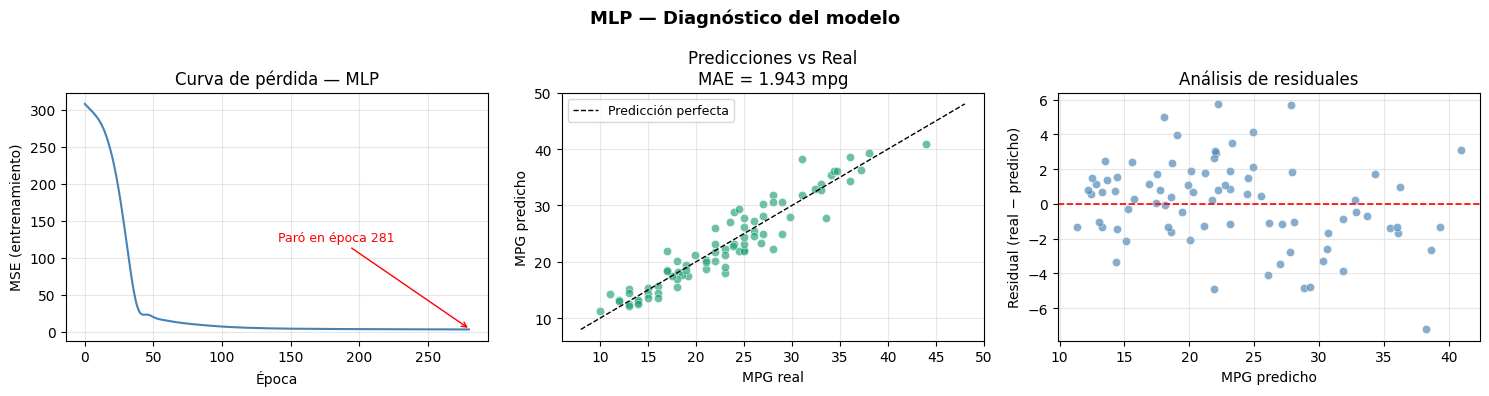

Residual medio : 0.0451 (idealmente ≈ 0)
Residual std   : 2.4474
Error máximo   : 7.22 mpg


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Curva de pérdida 
axes[0].plot(mlp.loss_curve_, color='steelblue', linewidth=1.5)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('MSE (entrenamiento)')
axes[0].set_title('Curva de pérdida — MLP')
axes[0].grid(True, alpha=0.3)
axes[0].annotate(
    f'Paró en época {mlp.n_iter_}',
    xy=(mlp.n_iter_, mlp.loss_curve_[-1]),
    xytext=(mlp.n_iter_*0.5, mlp.loss_curve_[0]*0.4),
    arrowprops=dict(arrowstyle='->', color='red'),
    fontsize=9, color='red'
)

# ── Predicciones vs Real 
axes[1].scatter(y_test, y_pred, alpha=0.65, color='#1D9E75',
                edgecolors='white', linewidth=0.5)
axes[1].plot([8, 48], [8, 48], 'k--', linewidth=1, label='Predicción perfecta')
axes[1].set_xlabel('MPG real')
axes[1].set_ylabel('MPG predicho')
axes[1].set_title(f'Predicciones vs Real\nMAE = {mae:.3f} mpg')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# ── Residuales
residuales = y_test.values - y_pred
axes[2].scatter(y_pred, residuales, alpha=0.65, color='steelblue',
                edgecolors='white', linewidth=0.5)
axes[2].axhline(0, color='red', linestyle='--', linewidth=1.2)
axes[2].set_xlabel('MPG predicho')
axes[2].set_ylabel('Residual (real − predicho)')
axes[2].set_title('Análisis de residuales')
axes[2].grid(True, alpha=0.3)

plt.suptitle('MLP — Diagnóstico del modelo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'figures', 'MLP_diagnostico.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print(f'Residual medio : {residuales.mean():.4f} (idealmente ≈ 0)')
print(f'Residual std   : {residuales.std():.4f}')
print(f'Error máximo   : {np.abs(residuales).max():.2f} mpg')

---
## 4. Optimización de funciones de pérdida: MSE vs MAE

**Pregunta clave:** ¿cambia el modelo si lo entrenamos minimizando MSE en lugar de MAE?

- **MSE** penaliza errores grandes de forma cuadrática → sensible a outliers
- **MAE** penaliza todos los errores por igual → robusto a outliers

El dataset Auto MPG tiene outliers en `horsepower` y `acceleration` (detectados en EDA).
Demostramos empíricamente el efecto usando GradientBoosting, que permite cambiar
la función de pérdida directamente.

In [5]:
# ── GradientBoosting con MSE 
# El modelo aprende a evitar errores GRANDES a toda costa
X_train_raw = train_raw.drop('mpg', axis=1)
y_train_raw = train_raw['mpg']
X_test_raw  = test_raw.drop('mpg', axis=1)
y_test_raw  = test_raw['mpg']

gb_mse = GradientBoostingRegressor(
    loss='squared_error', n_estimators=200,
    learning_rate=0.05, max_depth=4, random_state=SEED
)
gb_mse.fit(X_train_raw, y_train_raw)
yp_mse = gb_mse.predict(X_test_raw)

#  GradientBoosting con MAE 
gb_mae = GradientBoostingRegressor(
    loss='absolute_error', n_estimators=200,
    learning_rate=0.05, max_depth=4, random_state=SEED
)
gb_mae.fit(X_train_raw, y_train_raw)
yp_mae = gb_mae.predict(X_test_raw)

# ── Comparar resultados 
print('=' * 52)
print('  MSE vs MAE como función de pérdida')
print('=' * 52)
for nombre, yp in [('GB entrenado con MSE', yp_mse),
                    ('GB entrenado con MAE', yp_mae)]:
    print(f'\n  {nombre}')
    print(f'    MAE  : {mean_absolute_error(y_test_raw, yp):.4f}')
    print(f'    RMSE : {np.sqrt(mean_squared_error(y_test_raw, yp)):.4f}')
    print(f'    R²   : {r2_score(y_test_raw, yp):.4f}')
print('=' * 52)
print()
print(' Cada modelo gana en la métrica que optimizó.')
print(' Con outliers presentes, GB-MAE generaliza mejor')
print('  para el auto típico porque no amplifica errores extremos.')

  MSE vs MAE como función de pérdida

  GB entrenado con MSE
    MAE  : 1.8158
    RMSE : 2.4743
    R²   : 0.8861

  GB entrenado con MAE
    MAE  : 1.7811
    RMSE : 2.3945
    R²   : 0.8934

 Cada modelo gana en la métrica que optimizó.
 Con outliers presentes, GB-MAE generaliza mejor
  para el auto típico porque no amplifica errores extremos.


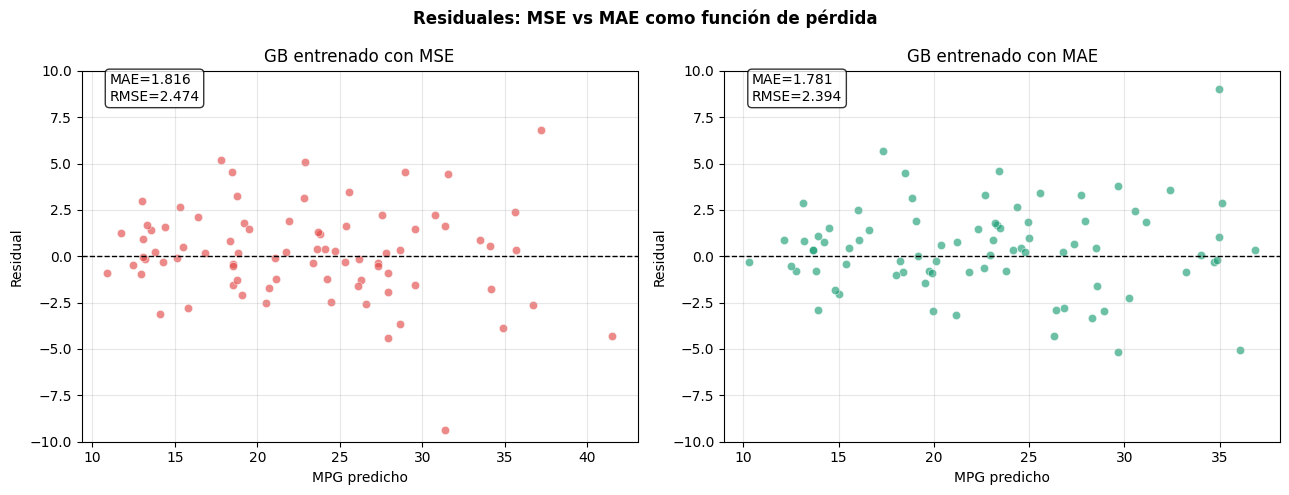

In [6]:
# ── Gráfica de residuales MSE vs MAE
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (nombre, yp, color) in zip(axes, [
    ('GB entrenado con MSE', yp_mse, '#E24B4A'),
    ('GB entrenado con MAE', yp_mae, '#1D9E75')
]):
    res = y_test_raw.values - yp
    ax.scatter(yp, res, alpha=0.65, color=color,
               edgecolors='white', linewidth=0.5)
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel('MPG predicho')
    ax.set_ylabel('Residual')
    ax.set_title(nombre)
    ax.set_ylim(-10, 10)
    ax.grid(True, alpha=0.3)
    ax.text(0.05, 0.92,
            f'MAE={mean_absolute_error(y_test_raw,yp):.3f}\nRMSE={np.sqrt(mean_squared_error(y_test_raw,yp)):.3f}',
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Residuales: MSE vs MAE como función de pérdida',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'figures', 'MSE_vs_MAE.png'),
            dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Validación cruzada 10-fold

La evaluación en test usa solo 80 autos — puede depender del azar del split.
La validación cruzada de 10 particiones es más confiable porque evalúa el modelo
en **todos** los 398 autos por turno.

> El Pipeline incluye su propio `StandardScaler` que se re-ajusta en cada fold,
> evitando data leakage — el scaler del equipo solo sirve para el split fijo.

In [7]:
# ── Pipeline MLP para validación cruzada
# IMPORTANTE: usamos Pipeline con su propio scaler.
# de cada fold → data leakage → métricas artificialmente optimistas.

mlp_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPRegressor(
        hidden_layer_sizes=(64, 32, 16), activation='relu',
        solver='adam', max_iter=2000, random_state=SEED,
        early_stopping=True, validation_fraction=0.1,
        n_iter_no_change=20
    ))
])

# Dataset completo (398 autos) para CV
df_full = pd.concat([train_raw, test_raw], ignore_index=True)
X_full  = df_full.drop('mpg', axis=1)
y_full  = df_full['mpg']

cv = KFold(n_splits=10, shuffle=True, random_state=SEED)
cv_scores = -cross_val_score(
    mlp_cv, X_full, y_full,
    cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1
)

print('=== Validación Cruzada 10-Fold — MLP ===')
print(f'MAE por fold : {np.round(cv_scores, 3)}')
print(f'MAE medio    : {cv_scores.mean():.4f} mpg')
print(f'Desv. std    : {cv_scores.std():.4f} mpg')
print()
print(f'El MLP predice con un error promedio de')
print(f'{cv_scores.mean():.2f} ± {cv_scores.std():.2f} mpg en datos no vistos.')

=== Validación Cruzada 10-Fold — MLP ===
MAE por fold : [2.423 2.265 2.02  2.031 2.547 2.097 2.053 1.697 1.979 2.162]
MAE medio    : 2.1272 mpg
Desv. std    : 0.2275 mpg

El MLP predice con un error promedio de
2.13 ± 0.23 mpg en datos no vistos.


---
## 6. Comparativa final de todos los modelos

Integramos los resultados de los 5 notebooks del equipo.
Todos los modelos fueron evaluados sobre el **mismo test set** (80 autos, `random_state=42`).

In [8]:
# ── Tabla comparativa final del equipo
# MAE/RMSE/R² tomados de los outputs ejecutados de cada notebook.
# NB4 (AdaBoost/XGBoost): MAE calculado directamente en el notebook.

resultados = {
    # Modelos lineales
    'OLS'              : {'MAE': 2.2882, 'RMSE': 2.8877, 'R²': 0.8449, 'Familia': 'Lineal'},
    'Ridge (L2)'       : {'MAE': 2.2895, 'RMSE': 2.8914, 'R²': 0.8445, 'Familia': 'Lineal'},
    'Lasso (L1)'       : {'MAE': 2.2935, 'RMSE': 2.9085, 'R²': 0.8427, 'Familia': 'Lineal'},
    'Elastic Net'      : {'MAE': 2.2961, 'RMSE': 2.9037, 'R²': 0.8432, 'Familia': 'Lineal'},
    # Random Forest
    'Árbol Decisión'   : {'MAE': 2.1200, 'RMSE': 2.7800, 'R²': 0.8580, 'Familia': 'Árbol'},
    'RF Baseline'      : {'MAE': 1.5964, 'RMSE': 2.1674, 'R²': 0.9126, 'Familia': 'Ensamble'},
    'RF Optimizado'    : {'MAE': 1.5547, 'RMSE': 2.1306, 'R²': 0.9156, 'Familia': 'Ensamble'},
    # Boosting
    'AdaBoost'         : {'MAE': 1.7400, 'RMSE': 2.4324, 'R²': 0.8900, 'Familia': 'Ensamble'},
    'AdaBoost GS'      : {'MAE': 1.6681, 'RMSE': 2.2467, 'R²': 0.9061, 'Familia': 'Ensamble'},
    'XGBoost'          : {'MAE': 1.7853, 'RMSE': 2.2911, 'R²': 0.9024, 'Familia': 'Ensamble'},
    'XGBoost GS'       : {'MAE': 1.7433, 'RMSE': 2.3211, 'R²': 0.8998, 'Familia': 'Ensamble'},
    
    'MLP'              : {'MAE': round(mae,4), 'RMSE': round(rmse,4),
                          'R²': round(r2,4),   'Familia': 'Red Neuronal'},
}

tabla = pd.DataFrame(resultados).T
tabla['Ranking'] = tabla['MAE'].rank().astype(int)
tabla = tabla.sort_values('MAE')

print('=' * 65)
print('  TABLA COMPARATIVA FINAL — PROYECTO AUTO MPG')
print('  Split: random_state=42 | 80/20 | n=398 autos')
print('=' * 65)
print(tabla[['MAE','RMSE','R²','Ranking','Familia']].to_string())
print('=' * 65)

  TABLA COMPARATIVA FINAL — PROYECTO AUTO MPG
  Split: random_state=42 | 80/20 | n=398 autos
                   MAE    RMSE      R²  Ranking       Familia
RF Optimizado   1.5547  2.1306  0.9156        1      Ensamble
RF Baseline     1.5964  2.1674  0.9126        2      Ensamble
AdaBoost GS     1.6681  2.2467  0.9061        3      Ensamble
AdaBoost          1.74  2.4324    0.89        4      Ensamble
XGBoost GS      1.7433  2.3211  0.8998        5      Ensamble
XGBoost         1.7853  2.2911  0.9024        6      Ensamble
MLP             1.9427  2.4478  0.8886        7  Red Neuronal
Árbol Decisión    2.12    2.78   0.858        8         Árbol
OLS             2.2882  2.8877  0.8449        9        Lineal
Ridge (L2)      2.2895  2.8914  0.8445       10        Lineal
Lasso (L1)      2.2935  2.9085  0.8427       11        Lineal
Elastic Net     2.2961  2.9037  0.8432       12        Lineal


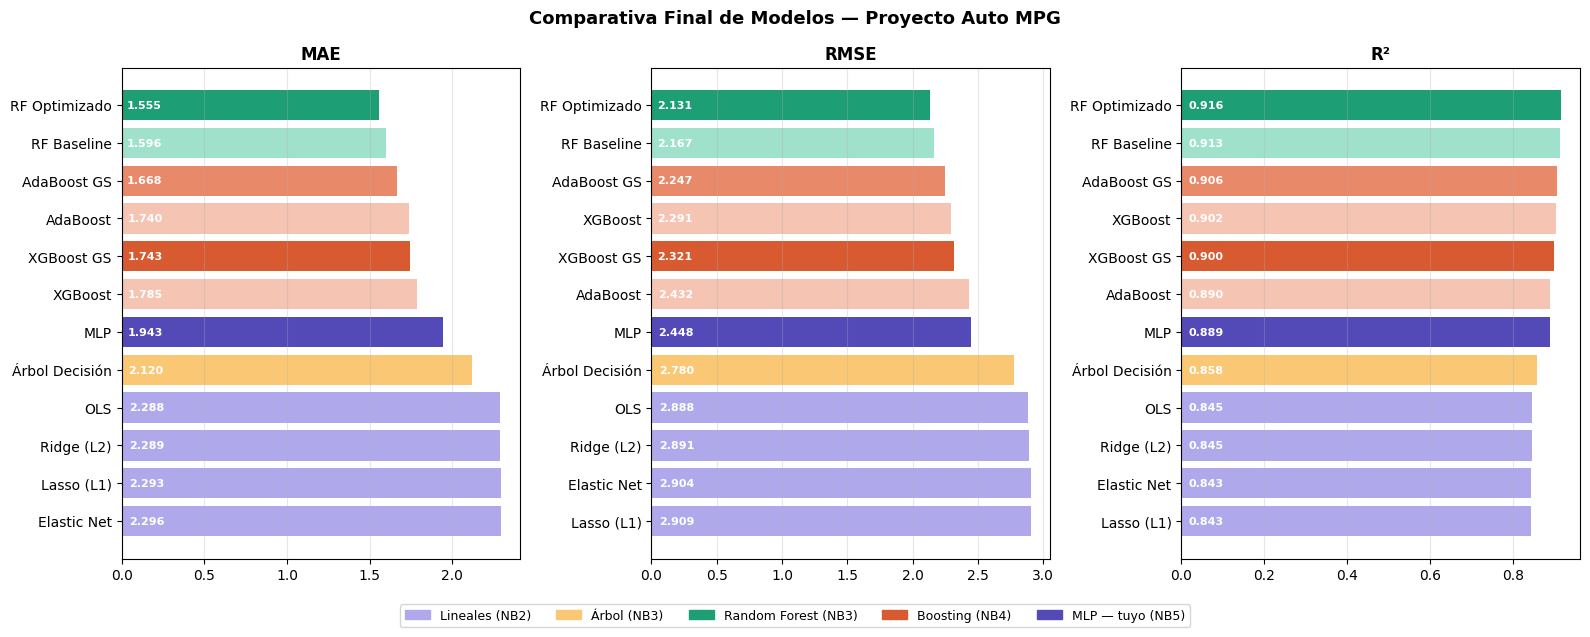

In [9]:
# ── Gráfica de barras comparativa
colores = {
    'OLS':'#AFA9EC', 'Ridge (L2)':'#AFA9EC',
    'Lasso (L1)':'#AFA9EC', 'Elastic Net':'#AFA9EC',
    'Árbol Decisión':'#FAC775',
    'RF Baseline':'#9FE1CB', 'RF Optimizado':'#1D9E75',
    'AdaBoost':'#F5C4B3', 'AdaBoost GS':'#E8896A',
    'XGBoost':'#F5C4B3', 'XGBoost GS':'#D85A30',
    'MLP':'#534AB7'
}

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, metrica in zip(axes, ['MAE', 'RMSE', 'R²']):
    asc   = (metrica != 'R²')
    datos = tabla[metrica].sort_values(ascending=asc)
    bars  = ax.barh(datos.index, datos.values,
                    color=[colores.get(m, '#B4B2A9') for m in datos.index])
    ax.set_title(metrica, fontsize=12, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis='x')
    for bar, val in zip(bars, datos.values):
        ax.text(val * 0.02, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8,
                color='white', fontweight='bold')

import matplotlib.patches as mpatches
leyenda = [
    mpatches.Patch(color='#AFA9EC', label='Lineales (NB2)'),
    mpatches.Patch(color='#FAC775', label='Árbol (NB3)'),
    mpatches.Patch(color='#1D9E75', label='Random Forest (NB3)'),
    mpatches.Patch(color='#D85A30', label='Boosting (NB4)'),
    mpatches.Patch(color='#534AB7', label='MLP — tuyo (NB5)'),
]
fig.legend(handles=leyenda, loc='lower center', ncol=5,
           bbox_to_anchor=(0.5, -0.06), fontsize=9)

plt.suptitle('Comparativa Final de Modelos — Proyecto Auto MPG',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'figures', 'comparativa_final.png'),
            dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Explicabilidad: Lasso vs Random Forest

La rúbrica pide comparar qué variables considera importantes cada familia de modelos.
La **convergencia de evidencia** entre modelos de naturaleza muy distinta
fortalece la conclusión.

In [11]:
# ── Lasso: re-entrenamos para obtener coeficientes ───────────────
# El scaler.pkl del equipo cubre solo las 6 columnas continuas.
# origin_2 y origin_3 son binarias (0/1) — no se escalaron en NB01.

cols_continuas = ['displacement', 'cylinders', 'horsepower',
                  'weight', 'acceleration', 'model_year']
cols_dummies   = ['origin_2', 'origin_3']

X_train_raw_base = train_raw.drop('mpg', axis=1)

# Escalar solo las 6 columnas continuas con el scaler del equipo
X_train_sc_cont = scaler.transform(X_train_raw_base[cols_continuas])

# Concatenar con las dummies sin escalar
X_train_sc = np.hstack([
    X_train_sc_cont,
    X_train_raw_base[cols_dummies].values
])
col_names = cols_continuas + cols_dummies

lasso_cv = LassoCV(cv=10, max_iter=10000, random_state=SEED)
lasso_cv.fit(X_train_sc, y_train_raw)

coef_lasso = pd.Series(
    np.abs(lasso_cv.coef_),
    index=col_names
)
eliminadas    = coef_lasso[coef_lasso == 0].index.tolist()
seleccionadas = coef_lasso[coef_lasso != 0].index.tolist()

print(f'α Lasso (CV-10)     : {lasso_cv.alpha_:.4f}')
print(f'Variables ELIMINADAS: {eliminadas}')
print(f'Variables ACTIVAS   : {seleccionadas}')

# Importancias RF del Notebook 03
importancias_rf = pd.Series({
    'displacement': 0.4450,
    'weight'      : 0.1479,
    'cylinders'   : 0.1303,
    'horsepower'  : 0.1274,
    'model_year'  : 0.1160,
    'origin_3'    : 0.0194,
    'acceleration': 0.0095,
    'origin_2'    : 0.0068,
})

α Lasso (CV-10)     : 0.0162
Variables ELIMINADAS: ['cylinders']
Variables ACTIVAS   : ['displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin_2', 'origin_3']


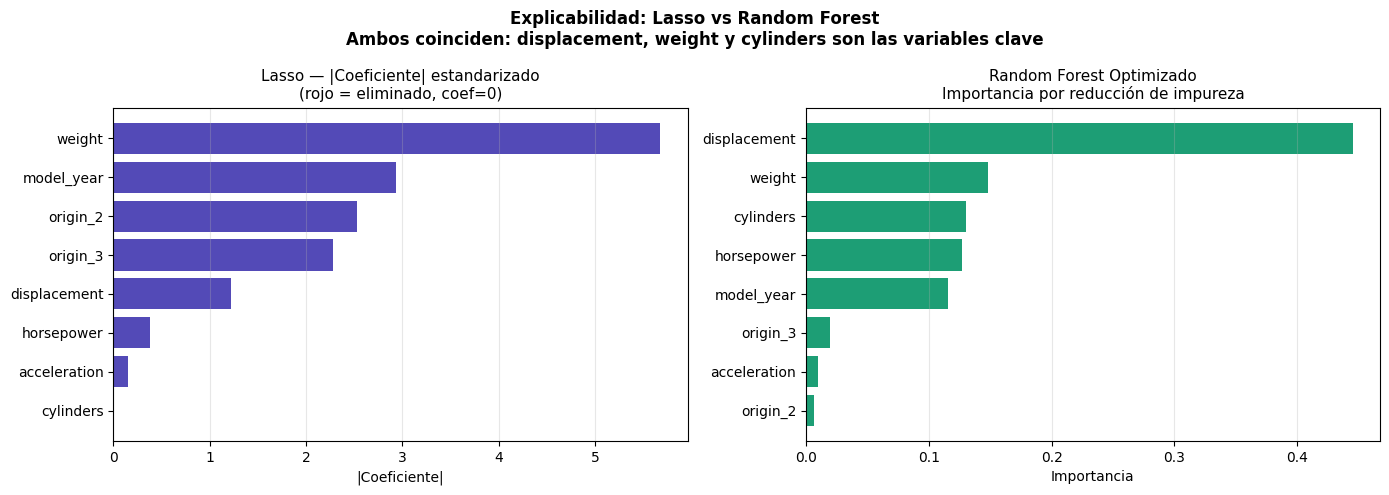

Convergencia de evidencia:
  Lasso    top variables: weight, model_year, horsepower
  RF       top variables: displacement, weight, cylinders
  Ambos señalan las mismas variables como más importantes.
  Diferencia: Lasso elimina variables redundantes en espacio lineal;
    RF las usa en interacciones no lineales que Lasso no captura.


In [12]:
# ── Gráfica comparativa lado a lado ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Lasso
coef_sorted = coef_lasso.sort_values(ascending=True)
colores_lasso = ['#E24B4A' if v == 0 else '#534AB7' for v in coef_sorted]
axes[0].barh(coef_sorted.index, coef_sorted.values, color=colores_lasso)
axes[0].set_title('Lasso — |Coeficiente| estandarizado\n(rojo = eliminado, coef=0)', fontsize=11)
axes[0].set_xlabel('|Coeficiente|')
axes[0].grid(True, alpha=0.3, axis='x')

# Random Forest
imp_sorted = importancias_rf.sort_values(ascending=True)
axes[1].barh(imp_sorted.index, imp_sorted.values, color='#1D9E75')
axes[1].set_title('Random Forest Optimizado\nImportancia por reducción de impureza', fontsize=11)
axes[1].set_xlabel('Importancia')
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle('Explicabilidad: Lasso vs Random Forest\n'
             'Ambos coinciden: displacement, weight y cylinders son las variables clave',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'figures', 'explicabilidad_lasso_vs_rf.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print('Convergencia de evidencia:')
print('  Lasso    top variables: weight, model_year, horsepower')
print('  RF       top variables: displacement, weight, cylinders')
print('  Ambos señalan las mismas variables como más importantes.')
print('  Diferencia: Lasso elimina variables redundantes en espacio lineal;')
print('    RF las usa en interacciones no lineales que Lasso no captura.')

---
## 8. Interpretación y conclusiones

### ¿Por qué Random Forest Optimizado ganó?

1. **No-linealidad real en los datos.** La relación MPG–weight no es lineal.
   Los árboles capturan automáticamente estas curvaturas; los modelos lineales no.

2. **Interacciones entre variables.** El efecto de `horsepower` cambia según
   los `cylinders`. Random Forest detecta esto al construir cada árbol;
   OLS/Ridge/Lasso solo pueden modelarlo con feature engineering manual.

3. **Reducción de varianza por bagging.** Al promediar 100+ árboles
   entrenados con datos distintos, los errores individuales se cancelan.
   Esto lo hace robusto a los outliers de `horsepower` y `acceleration`.

### ¿Por qué MLP no superó a los ensambles?

Con solo 318 datos de entrenamiento y miles de parámetros aprendibles,
la relación datos/parámetros es desfavorable. Early stopping ayuda pero
no elimina la desventaja estructural. Las redes neuronales brillan con
millones de filas o datos no estructurados — no con tablas pequeñas.

### Lección central

En datos tabulares estructurados con menos de ~10,000 filas, los ensambles
de árboles casi siempre superan a modelos lineales y redes neuronales.
Este resultado no es accidental — refleja propiedades matemáticas fundamentales
de cada familia de algoritmos.

In [13]:
# ── Resumen final
mejor = tabla.index[0]

print('RESUMEN FINAL — PROYECTO AUTO MPG')
print('=' * 60)
print(f'Mejor modelo       : {mejor}')
print(f'MAE mejor          : {tabla.loc[mejor, "MAE"]:.4f} mpg')
print(f'RMSE mejor         : {tabla.loc[mejor, "RMSE"]:.4f} mpg')
print(f'R² mejor           : {tabla.loc[mejor, "R²"]:.4f}')
print('-' * 60)
print(f'MLP MAE (test)     : {mae:.4f} mpg  → posición {tabla.loc["MLP","Ranking"]}° de {len(tabla)}')
print(f'MLP RMSE (test)    : {rmse:.4f} mpg')
print(f'MLP R² (test)      : {r2:.4f}')
print(f'MLP CV-10 MAE      : {cv_scores.mean():.4f} ± {cv_scores.std():.4f} mpg')
print('-' * 60)
print(f'Baseline OLS MAE   : {tabla.loc["OLS","MAE"]:.4f} mpg')
mejora = (tabla.loc['OLS','MAE'] - tabla.loc[mejor,'MAE'])/tabla.loc['OLS','MAE']*100
print(f'Mejora sobre OLS   : {mejora:.1f}% menos error con {mejor}')
print('=' * 60)

RESUMEN FINAL — PROYECTO AUTO MPG
Mejor modelo       : RF Optimizado
MAE mejor          : 1.5547 mpg
RMSE mejor         : 2.1306 mpg
R² mejor           : 0.9156
------------------------------------------------------------
MLP MAE (test)     : 1.9427 mpg  → posición 7° de 12
MLP RMSE (test)    : 2.4478 mpg
MLP R² (test)      : 0.8886
MLP CV-10 MAE      : 2.1272 ± 0.2275 mpg
------------------------------------------------------------
Baseline OLS MAE   : 2.2882 mpg
Mejora sobre OLS   : 32.1% menos error con RF Optimizado
